# 🏦 Home Credit Default Risk — Analisi del Rischio di Credito

## Obiettivo
Costruire un modello predittivo capace di identificare i clienti ad alto rischio 
di default su un prestito, supportando le decisioni di erogazione del credito.

## Approccio
Il progetto segue il ciclo di vita completo del dato:
1. Esplorazione e comprensione dei dati
2. Pre-processing e gestione dei valori mancanti
3. Valutazione e gestione dello sbilanciamento delle classi
4. Confronto di modelli con valutazione
5. Feature engineering da 6 sorgenti dati esterne
6. Ottimizzazione degli iperparametri con Optuna
7. Interpretabilità con SHAP e risposta aziendale

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, recall_score, precision_recall_curve,
    confusion_matrix
)
import optuna
import shap
import numpy as np
import pandas as pd
import os

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(filename)

sample_submission.csv
bureau_balance.csv
POS_CASH_balance.csv
application_train.csv
HomeCredit_columns_description.csv
application_test.csv
previous_application.csv
credit_card_balance.csv
installments_payments.csv
bureau.csv


## 1. Esplorazione e comprensione dei dati

Il dataset principale `application_train.csv` contiene **307.511 clienti** e **120 feature**
che descrivono lo snapshot del cliente al momento della richiesta di prestito.

### Target

La variabile target è binaria: **1 = default**, **0 = non default**.
Il dataset è fortemente sbilanciato: circa il **91.93% dei clienti non va in default**,
solo l'**8.07% sì**. Questo rende l'accuracy una metrica inutile —
un modello che predice sempre "non default" arriverebbe al 91.93% senza imparare nulla.
Le metriche rilevanti sono **Recall, F1 e AUC-ROC**.

### Ispezione delle Feature

La prima fase consiste nell'ispezionare il dataset: capire cosa rappresenta ogni colonna,
quali hanno valori mancanti e quali sono effettivamente utili alla predizione.
Utilizzando `HomeCredit_columns_description.csv` come riferimento, valutiamo
ogni colonna e identifichiamo quelle da rimuovere — la rimozione avverrà
nella fase di pre-processing.

### Osservazioni Chiave
- **EXT_SOURCE_2** e **EXT_SOURCE_3** sono rating creditizi esterni: valori bassi
  correlano fortemente con il default — saranno i predittori più potenti del modello.
- **DAYS_BIRTH** e **DAYS_EMPLOYED** sono espressi in giorni negativi rispetto alla
  data della domanda. `DAYS_EMPLOYED = 365243` è un placeholder per
  pensionati/disoccupati — viene sostituito con `NaN` già in questa fase
  prima di procedere con l'analisi esplorativa.
- Il dataset da solo non è sufficiente: manca la **storia comportamentale** del cliente.
  Il Feature Engineering da 6 sorgenti esterne è fondamentale per modellare il rischio reale.

In [3]:
df = pd.read_csv(dirname + '/application_train.csv', index_col='SK_ID_CURR')
display(df.head())
display(df.describe())
df.info()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,3522.886321,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,-24672.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,-7479.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,-4504.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,-2010.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


<class 'pandas.core.frame.DataFrame'>
Index: 307511 entries, 100002 to 456255
Columns: 121 entries, TARGET to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), object(16)
memory usage: 286.2+ MB


Valori mancanti TARGET: 0
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


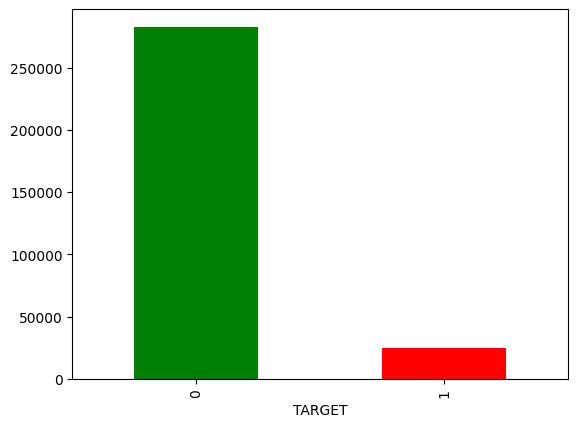

In [4]:
print("Valori mancanti TARGET:", df.TARGET.isnull().sum())
print((df['TARGET'].value_counts(normalize=True) * 100).round(2))
df['TARGET'].value_counts().plot.bar(color=['green', 'red'])
plt.show()

In [5]:
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

In [6]:
num = df.select_dtypes(include='number').columns.tolist()
cat = df.select_dtypes(include=['object', 'category']).columns.tolist()

null = df.isnull().sum() / len(df) * 100
null = null[null > 0].sort_values(ascending=False)

print(f"Colonne numeriche: {len(num)}")
print(f"Colonne categoriche: {len(cat)}")
print(f"Colonne dati mancanti: {len(null)}")
print(round(null.head(10), 2))

Colonne numeriche: 105
Colonne categoriche: 16
Colonne dati mancanti: 68
COMMONAREA_MODE             69.87
COMMONAREA_MEDI             69.87
COMMONAREA_AVG              69.87
NONLIVINGAPARTMENTS_AVG     69.43
NONLIVINGAPARTMENTS_MODE    69.43
NONLIVINGAPARTMENTS_MEDI    69.43
FONDKAPREMONT_MODE          68.39
LIVINGAPARTMENTS_MODE       68.35
LIVINGAPARTMENTS_AVG        68.35
LIVINGAPARTMENTS_MEDI       68.35
dtype: float64


In [7]:
print("Colonne categoriche:", cat)
print(f"\nTotale: {len(cat)}")

for col in cat:
    n = df[col].nunique()
    valori = df[col].unique()[:3]
    print(f"{col}: {n} valori unici → es. {valori}")

Colonne categoriche: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Totale: 16
NAME_CONTRACT_TYPE: 2 valori unici → es. ['Cash loans' 'Revolving loans']
CODE_GENDER: 3 valori unici → es. ['M' 'F' 'XNA']
FLAG_OWN_CAR: 2 valori unici → es. ['N' 'Y']
FLAG_OWN_REALTY: 2 valori unici → es. ['Y' 'N']
NAME_TYPE_SUITE: 7 valori unici → es. ['Unaccompanied' 'Family' 'Spouse, partner']
NAME_INCOME_TYPE: 8 valori unici → es. ['Working' 'State servant' 'Commercial associate']
NAME_EDUCATION_TYPE: 5 valori unici → es. ['Secondary / secondary special' 'Higher education' 'Incomplete higher']
NAME_FAMILY_STATUS: 6 valori unici → es. ['Single / not married' 'Married' 'Civil marriage']
NAME_HOUSING_TYPE: 6 valori unici → 

## 2. Pre-processing e gestione dei valori mancanti

Le scelte adottate sono pensate per supportare il confronto tra modelli
della sezione 4, che richiedono input numerici e scalati. Il preprocessing
verrà eventualmente ridefinito in base al modello che risulterà migliore.

- **Rimozione manuale** delle colonne ritenute non rilevanti o con troppi
  valori mancanti: identificate nella fase di esplorazione tramite
  `HomeCredit_columns_description.csv` e rimosse con una lista esplicita
  prima del pre-processing.
- **Mediana** per le colonne numeriche: robusta agli outlier, più affidabile
  della media su distribuzioni asimmetriche come i dati finanziari.
- **Moda** per le colonne categoriche: valore più frequente come proxy
  del comportamento tipico.
- **One-Hot Encoding** con `drop_first=True` per evitare multicollinearità
  tra le variabili dummy.
- **StandardScaler** fittato solo sul train set per evitare data leakage
  verso il test set.

In [8]:
cols_to_drop = [
    'COMMONAREA_AVG',
    'COMMONAREA_MEDI',
    'COMMONAREA_MODE',
    'NONLIVINGAPARTMENTS_AVG',
    'NONLIVINGAPARTMENTS_MEDI',
    'NONLIVINGAPARTMENTS_MODE',
    'NONLIVINGAREA_AVG',
    'NONLIVINGAREA_MEDI',
    'NONLIVINGAREA_MODE',
    'LANDAREA_AVG',
    'LANDAREA_MEDI',
    'LANDAREA_MODE',
    'BASEMENTAREA_AVG',
    'BASEMENTAREA_MEDI',
    'BASEMENTAREA_MODE',
    'FLOORSMIN_AVG',
    'FLOORSMIN_MEDI',
    'FLOORSMIN_MODE',
    'YEARS_BUILD_AVG',
    'YEARS_BUILD_MEDI',
    'YEARS_BUILD_MODE',
    'EMERGENCYSTATE_MODE',
    'APARTMENTS_MEDI',
    'APARTMENTS_MODE',
    'LIVINGAREA_MEDI',
    'LIVINGAREA_MODE',
    'FLOORSMAX_MEDI',
    'FLOORSMAX_MODE',
    'ENTRANCES_MEDI',
    'ENTRANCES_MODE',
    'YEARS_BEGINEXPLUATATION_MEDI',
    'YEARS_BEGINEXPLUATATION_MODE'
]

df = df.drop(columns=cols_to_drop)

In [9]:
def preprocessing(df):
    df.columns = df.columns.str.lower()
    X = df.drop('target', axis=1)
    y = df['target']

    num_cols = X.select_dtypes(include='number').columns
    cat_cols = X.select_dtypes(include='object').columns

    for col in num_cols:
        X[col] = X[col].fillna(X[col].median())
    for col in cat_cols:
        X[col] = X[col].fillna(X[col].mode()[0])

    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    return X, y

In [10]:
X, y = preprocessing(df)

In [11]:
def scaler(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    
    scaler = StandardScaler()

    num_cols = X_train.select_dtypes(include='number').columns.tolist()

    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])
    
    return X_train, X_test, y_train, y_test

In [12]:
X_train, X_test, y_train, y_test = scaler(X, y)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)

Train set: (246008, 196)
Test set: (61503, 196)


## 3. Valutazione e gestione dello sbilanciamento delle classi

Il dataset è fortemente sbilanciato: ~92% non-default vs ~8% default.
Un modello addestrato su dati sbilanciati tende a predire sempre la classe 
maggioritaria, ottenendo alta accuratezza ma recall bassissima sulla classe 
che ci interessa — i clienti a rischio.

Vengono confrontati tre approcci:
- **Class Weight**: penalizza il modello quando sbaglia sulla classe minoritaria.
  Non modifica i dati, solo i pesi nell'ottimizzazione.
- **SMOTE**: crea clienti sintetici interpolando quelli reali della classe minoritaria.
  Efficace con poche variabili numeriche, meno stabile con dataset ad alta dimensionalità.
- **Undersampling**: riduce la classe maggioritaria. Semplice ma butta via dati reali.

In [13]:
def balanced(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    under = RandomUnderSampler(random_state=42)
    X_train_under, y_train_under = under.fit_resample(X_train, y_train)

    return X_train_smote, y_train_smote, X_train_under, y_train_under

In [14]:
X_train_smote, y_train_smote, X_train_under, y_train_under = balanced(X_train, y_train)

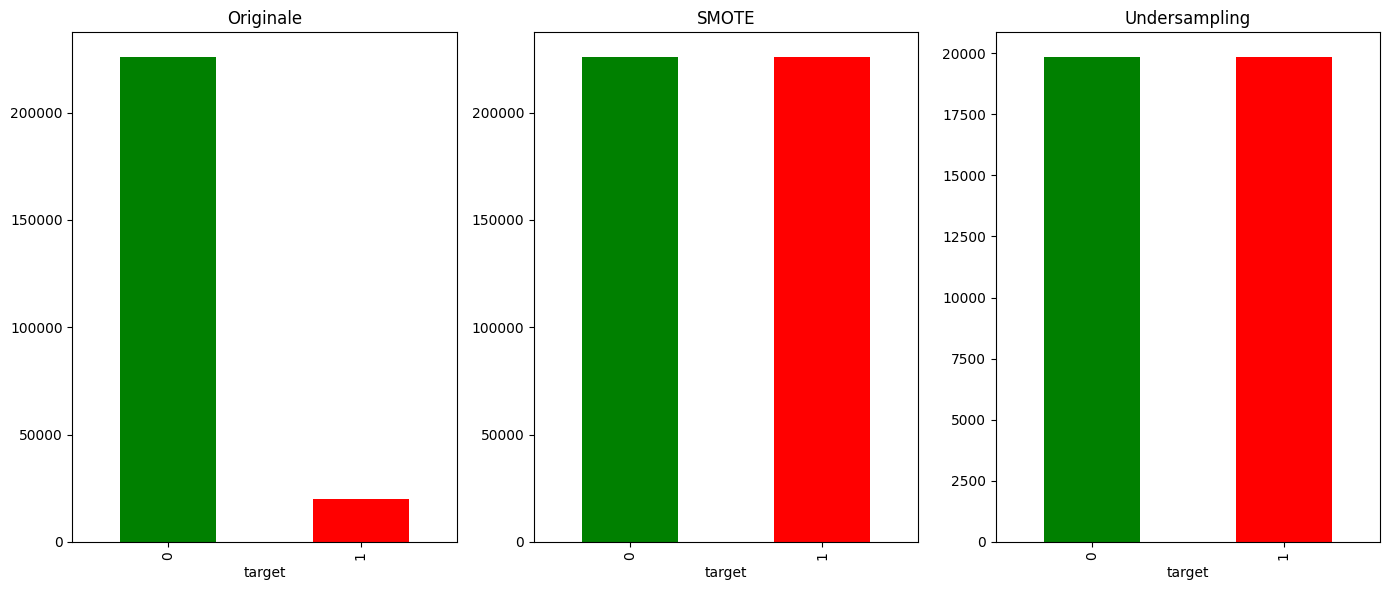

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

y_train.value_counts().plot.bar(ax=axes[0], color=['green', 'red'])
axes[0].set_title("Originale")

y_train_smote.value_counts().plot.bar(ax=axes[1], color=['green', 'red'])
axes[1].set_title("SMOTE")

y_train_under.value_counts().plot.bar(ax=axes[2], color=['green', 'red'])
axes[2].set_title("Undersampling")

plt.tight_layout()
plt.show()

In [16]:
def evaluate_method(methods):
    results = []
    for name_method, (X_tr, y_tr) in methods.items():
        if name_method == 'Class Weight':
            model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
        else:
            model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        results.append({
            'Method': name_method,
            'Recall': round(recall_score(y_test, y_pred), 4),
            'F1': round(f1_score(y_test, y_pred), 4),
            'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4)
        })
    return pd.DataFrame(results)

methods = {
    'Class Weight': (X_train, y_train),
    'SMOTE': (X_train_smote, y_train_smote),
    'Undersampling': (X_train_under, y_train_under)
}

result_df = evaluate_method(methods)
print(result_df.sort_values('AUC-ROC', ascending=False))

          Method  Recall      F1  AUC-ROC
0   Class Weight  0.6788  0.2606   0.7490
2  Undersampling  0.6765  0.2590   0.7475
1          SMOTE  0.0550  0.0952   0.6825


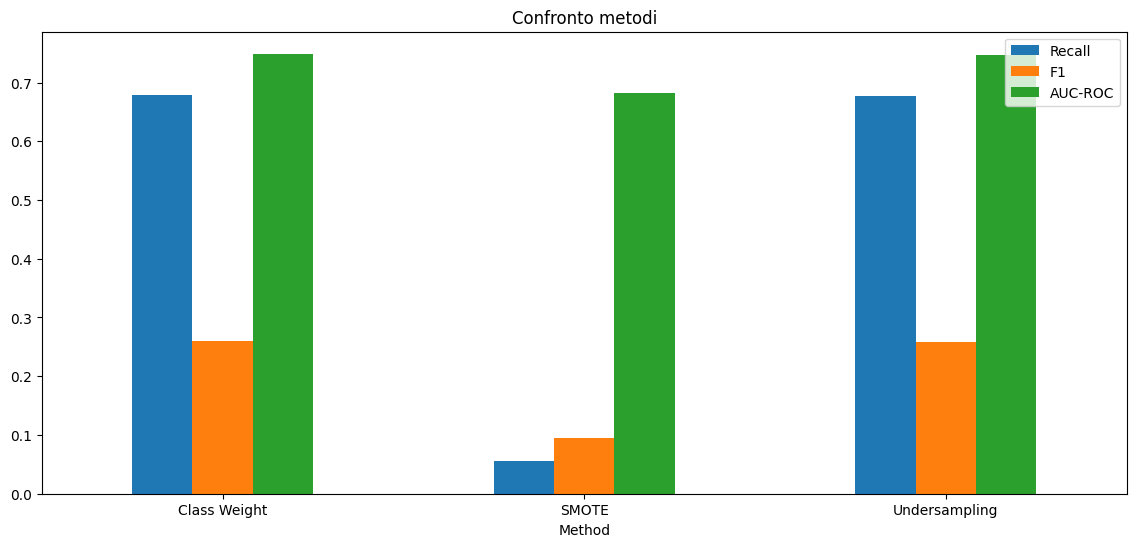

In [17]:
result_df.set_index('Method').plot.bar(figsize=(14, 6), title='Confronto metodi', rot=0)
plt.show()

## 4. Confronto di modelli con valutazione

Vengono confrontati tre modelli su train/test split stratificato (80/20):

| Modello | Caratteristica principale |
|---|---|
| Logistic Regression | Baseline lineare, interpretabile |
| Extra Trees | Ensemble parallelo, alberi con split casuali |
| XGBoost | Boosting sequenziale, cattura relazioni non lineari |

Logistic Regression e Extra Trees usano `class_weight='balanced'` per gestire
lo sbilanciamento. XGBoost usa `scale_pos_weight` — equivalente per gli alberi,
calcolato come rapporto reale tra classe maggioritaria e minoritaria.

Le metriche di riferimento sono **Recall**, **F1** e **AUC-ROC** —
l'accuracy non è rilevante su un dataset sbilanciato al 92/8%.

> **Nota:** il confronto si basa su un singolo split. I risultati
> sono indicativi e servono a selezionare il modello di partenza
> per l'ottimizzazione con Optuna — non costituiscono una
> valutazione statistica definitiva.

In [18]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

def evaluate_models(models):
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        results.append({
            'Model': name,
            'Recall':  round(recall_score(y_test, y_pred), 4),
            'F1':      round(f1_score(y_test, y_pred), 4),
            'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4),
        })
    return pd.DataFrame(results)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, scale_pos_weight=ratio,
        random_state=42, n_jobs=-1, verbosity=0, eval_metric='auc'
    ),
}

result_df = evaluate_models(models)
print(result_df.sort_values('AUC-ROC', ascending=False))

                 Model  Recall      F1  AUC-ROC
0  Logistic Regression  0.6788  0.2606   0.7490
2              XGBoost  0.6258  0.2735   0.7489
1          Extra Trees  0.0016  0.0032   0.7192


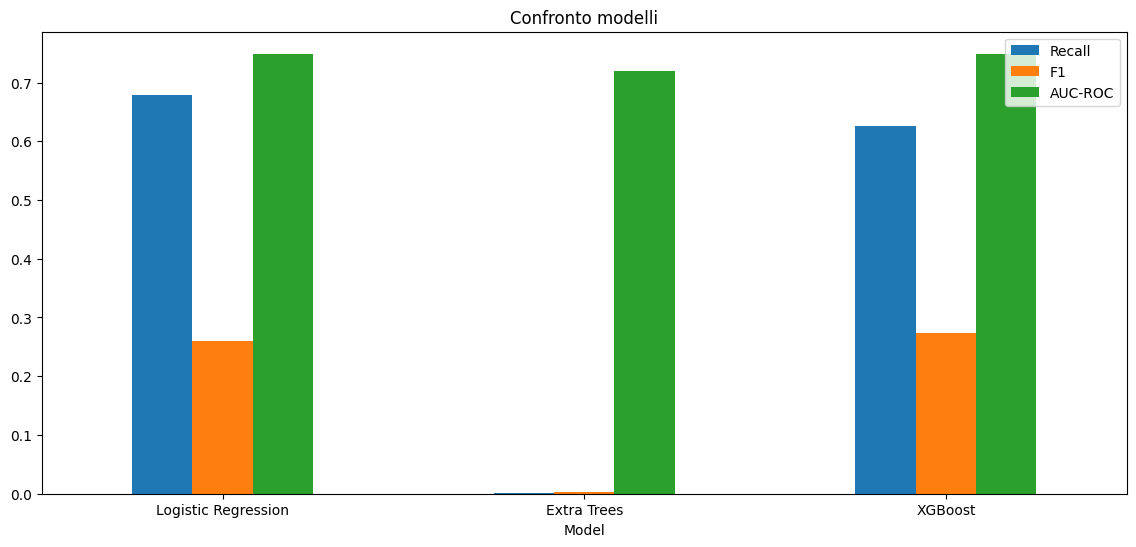

In [19]:
result_df.set_index('Model').plot.bar(figsize=(14, 6), title='Confronto modelli', rot=0)
plt.show()

### Conclusioni del confronto

Tra i tre metodi di gestione dello sbilanciamento, **Class Weight** ottiene
il miglior AUC-ROC mantenendo un buon equilibrio tra Recall e F1.
SMOTE e Undersampling introducono rispettivamente rumore sintetico e perdita
di dati reali, penalizzando la generalizzazione su un dataset di questa dimensione.

Tra i tre modelli testati, **Logistic Regression** e **XGBoost** ottengono
AUC-ROC sostanzialmente identico — una differenza che rientra nel rumore
di un singolo split. Extra Trees mostra un Recall quasi nullo alla soglia
default, segnale di una calibrazione delle probabilità non adeguata senza
un passaggio aggiuntivo con `CalibratedClassifierCV`.

Il Recall di Logistic è superiore a quello di XGBoost alla soglia 0.5,
ma questo confronto non è definitivo: il Recall dipende dalla soglia scelta,
che nella sezione 6 verrà ottimizzata esplicitamente sulla Precision-Recall
curve. A parità di AUC-ROC, entrambi i modelli possono raggiungere Recall
equivalenti agendo sulla soglia.

Questi risultati guidano le scelte successive:
- Il metodo **Class Weight** viene confermato come approccio al bilanciamento.
- Si passa a **XGBoost** come modello finale: a parità di AUC-ROC attuale,
  il vantaggio di XGBoost emergerà dopo il feature engineering, quando
  le interazioni non lineari tra storico crediti, ritardi e domande rifiutate
  daranno al boosting materiale che la regressione logistica non può catturare.
  Con Optuna la soglia verrà ottimizzata per massimizzare il Recall
  mantenendo una Precision minima — rendendo il confronto alla soglia 0.5
  non rilevante per la decisione finale.

## 5. Feature engineering da 6 sorgenti dati esterne

Il file application_train.csv contiene solo lo snapshot attuale del cliente.
Per predire il default in modo affidabile, il comportamento passato è
informazione fondamentale — "il miglior predittore del futuro è il passato".

Vengono integrati 6 file esterni, ognuno aggiunge una dimensione diversa:

| File | Cosa aggiunge |
|---|---|
| bureau.csv | Storico crediti con altre istituzioni |
| previous_application.csv | Domande di prestito precedenti con Home Credit |
| installments_payments.csv | Puntualità nei pagamenti a rate |
| POS_CASH_balance.csv | Prestiti POS e cash attivi/completati |
| credit_card_balance.csv | Utilizzo e ritardi su carte di credito |
| bureau_balance.csv | Comportamento mensile su quei crediti |

Dopo ogni file aggiunto viene misurato l'impatto sull'AUC-ROC tramite
**XGBoost** — il modello scelto come finale, usato qui senza ottimizzazione
degli iperparametri come proxy veloce per verificare che ogni sorgente
porti valore reale al modello.

In [20]:
bureau = pd.read_csv(dirname + '/bureau.csv')
display(bureau.head())
display(bureau.describe())
bureau.info()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
count,1.716428e+06,1.716428e+06,1.716428e+06,1.716428e+06,1.610875e+06,1.082775e+06,5.919400e+05,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06,1.716428e+06,1.716428e+06,4.896370e+05
mean,2.782149e+05,5.924434e+06,-1.142108e+03,8.181666e-01,5.105174e+02,-1.017437e+03,3.825418e+03,6.410406e-03,3.549946e+05,1.370851e+05,6.229515e+03,3.791276e+01,-5.937483e+02,1.571276e+04
std,1.029386e+05,5.322657e+05,7.951649e+02,3.654443e+01,4.994220e+03,7.140106e+02,2.060316e+05,9.622391e-02,1.149811e+06,6.774011e+05,4.503203e+04,5.937650e+03,7.207473e+02,3.258269e+05
min,1.000010e+05,5.000000e+06,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04,0.000000e+00
25%,1.888668e+05,5.463954e+06,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02,0.000000e+00
50%,2.780550e+05,5.926304e+06,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02,0.000000e+00
75%,3.674260e+05,6.385681e+06,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01,1.350000e+04
max,4.562550e+05,6.843457e+06,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,1.159872e+08,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02,1.184534e+08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [21]:
# Clip valori negativi non sensati
bureau['AMT_CREDIT_SUM_DEBT'] = bureau['AMT_CREDIT_SUM_DEBT'].clip(lower=0)

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    bureau_n_credit      = ('SK_ID_BUREAU', 'count'),
    bureau_first_credit  = ('DAYS_CREDIT', 'min'),
    bureau_max_overdue   = ('CREDIT_DAY_OVERDUE', 'max'),
    bureau_mean_overdue  = ('CREDIT_DAY_OVERDUE', 'mean'),
    bureau_total_debt    = ('AMT_CREDIT_SUM_DEBT', 'sum'),
    bureau_total_credit  = ('AMT_CREDIT_SUM', 'sum'),
    bureau_total_overdue = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    bureau_n_active      = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    bureau_n_closed      = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
).reset_index().set_index('SK_ID_CURR')

# Feature derivate con senso aziendale
bureau_agg['bureau_close_rate'] = (
    bureau_agg['bureau_n_closed'] /
    (bureau_agg['bureau_n_credit'] + 1)
)

bureau_agg['bureau_debt_ratio'] = (
    bureau_agg['bureau_total_debt'] /
    (bureau_agg['bureau_total_credit'] + 1)
)

display(bureau_agg.head())
display(bureau_agg.describe())
bureau_agg.info()

,bureau_n_credit,bureau_first_credit,bureau_max_overdue,bureau_mean_overdue,bureau_total_debt,bureau_total_credit,bureau_total_overdue,bureau_n_active,bureau_n_closed,bureau_close_rate,bureau_debt_ratio
SK_ID_CURR,,,,,,,,,,,
100001,7,-1572,0,0.0,596686.5,1453365.000,0.0,3,4,0.500000,0.410555
100002,8,-1437,0,0.0,245781.0,865055.565,0.0,2,6,0.666667,0.284121
100003,4,-2586,0,0.0,0.0,1017400.500,0.0,1,3,0.600000,0.000000
100004,2,-1326,0,0.0,0.0,189037.800,0.0,0,2,0.666667,0.000000
100005,3,-373,0,0.0,568408.5,657126.000,0.0,2,1,0.250000,0.864990


,bureau_n_credit,bureau_first_credit,bureau_max_overdue,bureau_mean_overdue,bureau_total_debt,bureau_total_credit,bureau_total_overdue,bureau_n_active,bureau_n_closed,bureau_close_rate,bureau_debt_ratio
count,305811.000000,305811.000000,305811.000000,305811.000000,3.058110e+05,3.058110e+05,3.058110e+05,305811.000000,305811.000000,305811.000000,3.058110e+05
mean,5.612709,-1764.362845,4.436629,0.965926,6.541292e+05,1.992466e+06,2.127933e+02,2.062081,3.529216,0.462803,9.791567e+00
std,4.430354,859.260807,85.573591,24.957209,1.640573e+06,4.165820e+06,1.569161e+04,1.791724,3.430504,0.239494,4.100454e+03
min,1.000000,-2922.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,2.000000,-2583.000000,0.000000,0.000000,0.000000e+00,3.469676e+05,0.000000e+00,1.000000,1.000000,0.333333,0.000000e+00
50%,4.000000,-1822.000000,0.000000,0.000000,1.734480e+05,9.788207e+05,0.000000e+00,2.000000,3.000000,0.500000,2.089382e-01
75%,8.000000,-1045.000000,0.000000,0.000000,6.767629e+05,2.345121e+06,0.000000e+00,3.000000,5.000000,0.666667,4.807450e-01
max,116.000000,0.000000,2792.000000,2776.000000,3.344983e+08,1.017958e+09,3.756681e+06,32.000000,108.000000,0.976744,2.250000e+06


<class 'pandas.core.frame.DataFrame'>
Index: 305811 entries, 100001 to 456255
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   bureau_n_credit       305811 non-null  int64  
 1   bureau_first_credit   305811 non-null  int64  
 2   bureau_max_overdue    305811 non-null  int64  
 3   bureau_mean_overdue   305811 non-null  float64
 4   bureau_total_debt     305811 non-null  float64
 5   bureau_total_credit   305811 non-null  float64
 6   bureau_total_overdue  305811 non-null  float64
 7   bureau_n_active       305811 non-null  int64  
 8   bureau_n_closed       305811 non-null  int64  
 9   bureau_close_rate     305811 non-null  float64
 10  bureau_debt_ratio     305811 non-null  float64
dtypes: float64(6), int64(5)
memory usage: 28.0 MB


In [22]:
df_fe = df.join(bureau_agg, how='left')
bureau_col = bureau_agg.columns.tolist()
df_fe[bureau_col] = df_fe[bureau_col].fillna(0)

print("Dimensioni:", df_fe.shape)
df_fe.head()

Dimensioni: (307511, 100)


,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,...,bureau_first_credit,bureau_max_overdue,bureau_mean_overdue,bureau_total_debt,bureau_total_credit,bureau_total_overdue,bureau_n_active,bureau_n_closed,bureau_close_rate,bureau_debt_ratio
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,-1437.0,0.0,0.0,245781.0,865055.565,0.0,2.0,6.0,0.666667,0.284121
100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,-2586.0,0.0,0.0,0.0,1017400.500,0.0,1.0,3.0,0.600000,0.000000
100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,-1326.0,0.0,0.0,0.0,189037.800,0.0,0.0,2.0,0.666667,0.000000
100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000000,0.000000
100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,-1149.0,0.0,0.0,0.0,146250.000,0.0,0.0,1.0,0.500000,0.000000


In [23]:
def preprocessing_xgb(df, test_size=0.2, random_state=42):
    df.columns = df.columns.str.lower()
    X = df.drop('target', axis=1)
    y = df['target']

    cat_cols = X.select_dtypes(include='object').columns
    X[cat_cols] = X[cat_cols].astype('category')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    return X_train, X_test, y_train, y_test

In [24]:
X_train, X_test, y_train, y_test = preprocessing_xgb(df_fe)

In [25]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

def evaluate(X_train, X_test, y_train, y_test):
    results = []
    model = XGBClassifier(
        n_estimators=100, scale_pos_weight=ratio,
        random_state=42, n_jobs=-1, verbosity=0, eval_metric='auc',
        enable_categorical=True, tree_method='hist'
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Recall':  round(recall_score(y_test, y_pred), 4),
        'F1':      round(f1_score(y_test, y_pred), 4),
        'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4),
    })
    return pd.DataFrame(results)

In [26]:
result_df = evaluate(X_train, X_test, y_train, y_test)
print(result_df)

   Recall      F1  AUC-ROC
0  0.5968  0.2794   0.7449


In [27]:
prev = pd.read_csv(dirname + '/previous_application.csv')
display(prev.head())
display(prev.describe())
prev.info()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


,SK_ID_PREV,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,...,RATE_INTEREST_PRIVILEGED,DAYS_DECISION,SELLERPLACE_AREA,CNT_PAYMENT,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
count,1.670214e+06,1.670214e+06,1.297979e+06,1.670214e+06,1.670213e+06,7.743700e+05,1.284699e+06,1.670214e+06,1.670214e+06,774370.000000,...,5951.000000,1.670214e+06,1.670214e+06,1.297984e+06,997149.000000,997149.000000,997149.000000,997149.000000,997149.000000,997149.000000
mean,1.923089e+06,2.783572e+05,1.595512e+04,1.752339e+05,1.961140e+05,6.697402e+03,2.278473e+05,1.248418e+01,9.964675e-01,0.079637,...,0.773503,-8.806797e+02,3.139511e+02,1.605408e+01,342209.855039,13826.269337,33767.774054,76582.403064,81992.343838,0.332570
std,5.325980e+05,1.028148e+05,1.478214e+04,2.927798e+05,3.185746e+05,2.092150e+04,3.153966e+05,3.334028e+00,5.932963e-02,0.107823,...,0.100879,7.790997e+02,7.127443e+03,1.456729e+01,88916.115834,72444.869708,106857.034789,149647.415123,153303.516729,0.471134
min,1.000001e+06,1.000010e+05,0.000000e+00,0.000000e+00,0.000000e+00,-9.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,-0.000015,...,0.373150,-2.922000e+03,-1.000000e+00,0.000000e+00,-2922.000000,-2892.000000,-2801.000000,-2889.000000,-2874.000000,0.000000
25%,1.461857e+06,1.893290e+05,6.321780e+03,1.872000e+04,2.416050e+04,0.000000e+00,5.084100e+04,1.000000e+01,1.000000e+00,0.000000,...,0.715645,-1.300000e+03,-1.000000e+00,6.000000e+00,365243.000000,-1628.000000,-1242.000000,-1314.000000,-1270.000000,0.000000
50%,1.923110e+06,2.787145e+05,1.125000e+04,7.104600e+04,8.054100e+04,1.638000e+03,1.123200e+05,1.200000e+01,1.000000e+00,0.051605,...,0.835095,-5.810000e+02,3.000000e+00,1.200000e+01,365243.000000,-831.000000,-361.000000,-537.000000,-499.000000,0.000000
75%,2.384280e+06,3.675140e+05,2.065842e+04,1.803600e+05,2.164185e+05,7.740000e+03,2.340000e+05,1.500000e+01,1.000000e+00,0.108909,...,0.852537,-2.800000e+02,8.200000e+01,2.400000e+01,365243.000000,-411.000000,129.000000,-74.000000,-44.000000,1.000000
max,2.845382e+06,4.562550e+05,4.180581e+05,6.905160e+06,6.905160e+06,3.060045e+06,6.905160e+06,2.300000e+01,1.000000e+00,1.000000,...,1.000000,-1.000000e+00,4.000000e+06,8.400000e+01,365243.000000,365243.000000,365243.000000,365243.000000,365243.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [28]:
# Sostituisci il placeholder con NaN — non sono date reali
days_cols = ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE',
             'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION']
for col in days_cols:
    prev[col] = prev[col].replace(365243, np.nan)

prev_agg = prev.groupby('SK_ID_CURR').agg(
    # Quante domande ha fatto in totale?
    prev_n_apps        = ('SK_ID_PREV', 'count'),

    # Quante approvate, rifiutate, cancellate?
    prev_n_approved    = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    prev_n_refused     = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    prev_n_canceled    = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),

    # Credito medio concesso — capacità riconosciuta dal mercato
    prev_mean_credit   = ('AMT_CREDIT', 'mean'),

    # Rate medie — abitudine a prestiti lunghi o corti
    prev_mean_payments = ('CNT_PAYMENT', 'mean'),

    # Ultima decisione — attività creditizia recente
    # max perché DAYS_DECISION è negativo — il meno negativo è il più recente
    prev_last_decision = ('DAYS_DECISION', 'max'),

).reset_index().set_index('SK_ID_CURR')

# Feature derivate con senso aziendale
# Tasso di rifiuto — quante domande su 10 sono state rifiutate?
prev_agg['prev_refuse_rate'] = (
    prev_agg['prev_n_refused'] /
    (prev_agg['prev_n_apps'] + 1)
)

# Tasso di approvazione
prev_agg['prev_approval_rate'] = (
    prev_agg['prev_n_approved'] /
    (prev_agg['prev_n_apps'] + 1)
)

print("Dimensioni prev_agg:", prev_agg.shape)
prev_agg.head()

Dimensioni prev_agg: (338857, 9)


,prev_n_apps,prev_n_approved,prev_n_refused,prev_n_canceled,prev_mean_credit,prev_mean_payments,prev_last_decision,prev_refuse_rate,prev_approval_rate
SK_ID_CURR,,,,,,,,,
100001,1,1,0,0,23787.00,8.0,-1740,0.0,0.500000
100002,1,1,0,0,179055.00,24.0,-606,0.0,0.500000
100003,3,3,0,0,484191.00,10.0,-746,0.0,0.750000
100004,1,1,0,0,20106.00,4.0,-815,0.0,0.500000
100005,2,1,0,1,20076.75,12.0,-315,0.0,0.333333


In [29]:
df_fe = df_fe.join(prev_agg, how='left')
prev_col = prev_agg.columns.tolist()
df_fe[prev_col] = df_fe[prev_col].fillna(0)

print("Dimensioni:", df_fe.shape)

Dimensioni: (307511, 109)


In [30]:
X_train, X_test, y_train, y_test = preprocessing_xgb(df_fe)
result_df = evaluate(X_train, X_test, y_train, y_test)
print(result_df)

   Recall      F1  AUC-ROC
0  0.5893  0.2851   0.7476


In [31]:
inst = pd.read_csv(dirname + '/installments_payments.csv')
display(inst.head())
display(inst.describe())
inst.info()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
count,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360250e+07,1.360540e+07,1.360250e+07
mean,1.903365e+06,2.784449e+05,8.566373e-01,1.887090e+01,-1.042270e+03,-1.051114e+03,1.705091e+04,1.723822e+04
std,5.362029e+05,1.027183e+05,1.035216e+00,2.666407e+01,8.009463e+02,8.005859e+02,5.057025e+04,5.473578e+04
min,1.000001e+06,1.000010e+05,0.000000e+00,1.000000e+00,-2.922000e+03,-4.921000e+03,0.000000e+00,0.000000e+00
25%,1.434191e+06,1.896390e+05,0.000000e+00,4.000000e+00,-1.654000e+03,-1.662000e+03,4.226085e+03,3.398265e+03
50%,1.896520e+06,2.786850e+05,1.000000e+00,8.000000e+00,-8.180000e+02,-8.270000e+02,8.884080e+03,8.125515e+03
75%,2.369094e+06,3.675300e+05,1.000000e+00,1.900000e+01,-3.610000e+02,-3.700000e+02,1.671021e+04,1.610842e+04
max,2.843499e+06,4.562550e+05,1.780000e+02,2.770000e+02,-1.000000e+00,-1.000000e+00,3.771488e+06,3.771488e+06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


In [32]:
# Giorni di ritardo — positivo = ritardo, negativo = anticipo
inst['days_late'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']

# Differenza importo — positivo = ha pagato meno del dovuto
inst['amt_diff'] = inst['AMT_INSTALMENT'] - inst['AMT_PAYMENT']

inst_agg = inst.groupby('SK_ID_CURR').agg(
    # Quante rate ha pagato in totale?
    inst_n_payments      = ('SK_ID_PREV', 'count'),

    # Ritardo medio — pattern generale di comportamento
    inst_mean_late       = ('days_late', 'mean'),

    # Ritardo massimo — il peggiore episodio
    inst_max_late        = ('days_late', 'max'),

    # Quante rate ha pagato in ritardo?
    inst_n_late          = ('days_late', lambda x: (x > 0).sum()),

    # Differenza media importo — paga sempre meno del dovuto?
    inst_mean_amt_diff   = ('amt_diff', 'mean'),

    # Differenza totale — debito accumulato per pagamenti parziali
    inst_total_amt_diff  = ('amt_diff', 'sum'),

).reset_index().set_index('SK_ID_CURR')

# Feature derivate
# Percentuale rate in ritardo — più stabile del numero assoluto
inst_agg['inst_late_rate'] = (
    inst_agg['inst_n_late'] /
    (inst_agg['inst_n_payments'] + 1)
)

print("Dimensioni inst_agg:", inst_agg.shape)
inst_agg.head()

Dimensioni inst_agg: (339587, 7)


,inst_n_payments,inst_mean_late,inst_max_late,inst_n_late,inst_mean_amt_diff,inst_total_amt_diff,inst_late_rate
SK_ID_CURR,,,,,,,
100001,7,-7.285714,11.0,1,0.0,0.0,0.125
100002,19,-20.421053,-12.0,0,0.0,0.0,0.000
100003,25,-7.160000,-1.0,0,0.0,0.0,0.000
100004,3,-7.666667,-3.0,0,0.0,0.0,0.000
100005,9,-23.555556,1.0,1,0.0,0.0,0.100


In [33]:
df_fe = df_fe.join(inst_agg, how='left')
inst_col = inst_agg.columns.tolist()
df_fe[inst_col] = df_fe[inst_col].fillna(0)

print("Dimensioni:", df_fe.shape)

Dimensioni: (307511, 116)


In [34]:
X_train, X_test, y_train, y_test = preprocessing_xgb(df_fe)
result_df = evaluate(X_train, X_test, y_train, y_test)
print(result_df)

   Recall      F1  AUC-ROC
0  0.5907  0.2854   0.7527


In [35]:
pos = pd.read_csv(dirname + '/POS_CASH_balance.csv')
display(pos.head())
display(pos.describe())
pos.info()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,SK_DPD,SK_DPD_DEF
count,1.000136e+07,1.000136e+07,1.000136e+07,9.975287e+06,9.975271e+06,1.000136e+07,1.000136e+07
mean,1.903217e+06,2.784039e+05,-3.501259e+01,1.708965e+01,1.048384e+01,1.160693e+01,6.544684e-01
std,5.358465e+05,1.027637e+05,2.606657e+01,1.199506e+01,1.110906e+01,1.327140e+02,3.276249e+01
min,1.000001e+06,1.000010e+05,-9.600000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434405e+06,1.895500e+05,-5.400000e+01,1.000000e+01,3.000000e+00,0.000000e+00,0.000000e+00
50%,1.896565e+06,2.786540e+05,-2.800000e+01,1.200000e+01,7.000000e+00,0.000000e+00,0.000000e+00
75%,2.368963e+06,3.674290e+05,-1.300000e+01,2.400000e+01,1.400000e+01,0.000000e+00,0.000000e+00
max,2.843499e+06,4.562550e+05,-1.000000e+00,9.200000e+01,8.500000e+01,4.231000e+03,3.595000e+03


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


In [36]:
pos_agg = pos.groupby('SK_ID_CURR').agg(
    # Quanti mesi di storia ha?
    pos_n_months      = ('MONTHS_BALANCE', 'count'),

    # Ritardo medio mensile — pattern generale
    pos_mean_dpd      = ('SK_DPD', 'mean'),

    # Ritardo massimo — episodio peggiore
    pos_max_dpd       = ('SK_DPD', 'max'),

    # Quanti mesi era in ritardo?
    pos_n_dpd         = ('SK_DPD', lambda x: (x > 0).sum()),

    # Ritardo grave medio — solo gli episodi seri
    pos_mean_dpd_def  = ('SK_DPD_DEF', 'mean'),

    # Quanti mesi con ritardo grave?
    pos_n_dpd_def     = ('SK_DPD_DEF', lambda x: (x > 0).sum()),

    # Contratti completati — affidabilità
    pos_n_completed   = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),

    # Contratti attivi — esposizione attuale
    pos_n_active      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').sum()),

).reset_index().set_index('SK_ID_CURR')

# Feature derivata — percentuale mesi in ritardo
pos_agg['pos_dpd_rate'] = (
    pos_agg['pos_n_dpd'] /
    (pos_agg['pos_n_months'] + 1)
)

print("Dimensioni pos_agg:", pos_agg.shape)
pos_agg.head()

Dimensioni pos_agg: (337252, 9)


,pos_n_months,pos_mean_dpd,pos_max_dpd,pos_n_dpd,pos_mean_dpd_def,pos_n_dpd_def,pos_n_completed,pos_n_active,pos_dpd_rate
SK_ID_CURR,,,,,,,,,
100001,9,0.777778,7,1,0.777778,1,2,7,0.1
100002,19,0.000000,0,0,0.000000,0,0,19,0.0
100003,28,0.000000,0,0,0.000000,0,2,26,0.0
100004,4,0.000000,0,0,0.000000,0,1,3,0.0
100005,11,0.000000,0,0,0.000000,0,1,9,0.0


In [37]:
df_fe = df_fe.join(pos_agg, how='left')
pos_col = pos_agg.columns.tolist()
df_fe[pos_col] = df_fe[pos_col].fillna(0)

print("Dimensioni:", df_fe.shape)

Dimensioni: (307511, 125)


In [38]:
X_train, X_test, y_train, y_test = preprocessing_xgb(df_fe)
result_df = evaluate(X_train, X_test, y_train, y_test)
print(result_df)

   Recall      F1  AUC-ROC
0  0.5948  0.2888   0.7569


In [39]:
cc = pd.read_csv(dirname + '/credit_card_balance.csv')
display(cc.head())
display(cc.describe())
cc.info()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,SK_DPD,SK_DPD_DEF
count,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,...,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,3.840312e+06,3.840312e+06
mean,1.904504e+06,2.783242e+05,-3.452192e+01,5.830016e+04,1.538080e+05,5.961325e+03,7.433388e+03,2.881696e+02,2.968805e+03,3.540204e+03,...,5.596588e+04,5.808881e+04,5.809829e+04,3.094490e-01,7.031439e-01,4.812496e-03,5.594791e-01,2.082508e+01,9.283667e+00,3.316220e-01
std,5.364695e+05,1.027045e+05,2.666775e+01,1.063070e+05,1.651457e+05,2.822569e+04,3.384608e+04,8.201989e+03,2.079689e+04,5.600154e+03,...,1.025336e+05,1.059654e+05,1.059718e+05,1.100401e+00,3.190347e+00,8.263861e-02,3.240649e+00,2.005149e+01,9.751570e+01,2.147923e+01
min,1.000018e+06,1.000060e+05,-9.600000e+01,-4.202502e+05,0.000000e+00,-6.827310e+03,-6.211620e+03,0.000000e+00,0.000000e+00,0.000000e+00,...,-4.233058e+05,-4.202502e+05,-4.202502e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434385e+06,1.895170e+05,-5.500000e+01,0.000000e+00,4.500000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00
50%,1.897122e+06,2.783960e+05,-2.800000e+01,0.000000e+00,1.125000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,0.000000e+00
75%,2.369328e+06,3.675800e+05,-1.100000e+01,8.904669e+04,1.800000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.633911e+03,...,8.535924e+04,8.889949e+04,8.891451e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00
max,2.843496e+06,4.562500e+05,-1.000000e+00,1.505902e+06,1.350000e+06,2.115000e+06,2.287098e+06,1.529847e+06,2.239274e+06,2.028820e+05,...,1.472317e+06,1.493338e+06,1.493338e+06,5.100000e+01,1.650000e+02,1.200000e+01,1.650000e+02,1.200000e+02,3.260000e+03,3.260000e+03


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

In [40]:
# Clip valori negativi non sensati
cc['AMT_BALANCE']              = cc['AMT_BALANCE'].clip(lower=0)
cc['AMT_DRAWINGS_ATM_CURRENT'] = cc['AMT_DRAWINGS_ATM_CURRENT'].clip(lower=0)

# Utilizzo del limite — quanto del credito disponibile sta usando?
# +1 per evitare divisione per zero
cc['credit_util'] = cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1)

cc_agg = cc.groupby('SK_ID_CURR').agg(
    # Quanti mesi di storia ha?
    cc_n_months       = ('MONTHS_BALANCE', 'count'),

    # Saldo medio — quanto debito medio sulla carta
    cc_mean_balance   = ('AMT_BALANCE', 'mean'),

    # Saldo massimo — picco di esposizione
    cc_max_balance    = ('AMT_BALANCE', 'max'),

    # Utilizzo medio del limite — il predittore più forte sulle carte
    cc_mean_util      = ('credit_util', 'mean'),

    # Utilizzo massimo del limite di credito
    cc_max_util       = ('credit_util', 'max'),

    # Prelievi ATM medi — uso della carta come prestito d'emergenza
    cc_mean_atm       = ('AMT_DRAWINGS_ATM_CURRENT', 'mean'),

    # Ritardo medio
    cc_mean_dpd       = ('SK_DPD', 'mean'),

    # Ritardo massimo
    cc_max_dpd        = ('SK_DPD', 'max'),

    # Quanti mesi con ritardo?
    cc_n_dpd          = ('SK_DPD', lambda x: (x > 0).sum()),

    # Importo minimo dovuto medio — proxy dell'esposizione contrattuale
    cc_mean_min_pay   = ('AMT_INST_MIN_REGULARITY', 'mean'),

).reset_index().set_index('SK_ID_CURR')

# Feature derivata — percentuale mesi in ritardo
cc_agg['cc_dpd_rate'] = (
    cc_agg['cc_n_dpd'] /
    (cc_agg['cc_n_months'] + 1)
)

print("Dimensioni cc_agg:", cc_agg.shape)
cc_agg.head()

Dimensioni cc_agg: (103558, 11)


,cc_n_months,cc_mean_balance,cc_max_balance,cc_mean_util,cc_max_util,cc_mean_atm,cc_mean_dpd,cc_max_dpd,cc_n_dpd,cc_mean_min_pay,cc_dpd_rate
SK_ID_CURR,,,,,,,,,,,
100006,6,0.000000,0.00,0.000000,0.000000,NaN,0.000000,0,0,0.000000,0.000000
100011,74,54482.111149,189000.00,0.302677,1.049994,2432.432432,0.000000,0,0,3956.221849,0.000000
100013,96,18159.919219,161420.22,0.115300,1.024884,6350.000000,0.010417,1,1,1454.539551,0.010309
100021,17,0.000000,0.00,0.000000,0.000000,NaN,0.000000,0,0,0.000000,0.000000
100023,8,0.000000,0.00,0.000000,0.000000,NaN,0.000000,0,0,0.000000,0.000000


In [41]:
df_fe = df_fe.join(cc_agg, how='left')
cc_col = cc_agg.columns.tolist()
df_fe[cc_col] = df_fe[cc_col].fillna(0)

print("Dimensioni:", df_fe.shape)

Dimensioni: (307511, 136)


In [42]:
X_train, X_test, y_train, y_test = preprocessing_xgb(df_fe)
result_df = evaluate(X_train, X_test, y_train, y_test)
print(result_df)

   Recall      F1  AUC-ROC
0  0.5903  0.2917   0.7584


In [43]:
bb = pd.read_csv(dirname + '/bureau_balance.csv')
display(bb.head())
display(bb.describe())
bb.info()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


,SK_ID_BUREAU,MONTHS_BALANCE
count,2.729992e+07,2.729992e+07
mean,6.036297e+06,-3.074169e+01
std,4.923489e+05,2.386451e+01
min,5.001709e+06,-9.600000e+01
25%,5.730933e+06,-4.600000e+01
50%,6.070821e+06,-2.500000e+01
75%,6.431951e+06,-1.100000e+01
max,6.842888e+06,0.000000e+00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


In [44]:
status_map = {'C': 0, 'X': 0, '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
bb['STATUS_NUM'] = bb['STATUS'].map(status_map)

# Passo 1 — aggrega su SK_ID_BUREAU
bb_agg = bb.groupby('SK_ID_BUREAU').agg(
    bb_max_delay      = ('STATUS_NUM', 'max'),
    bb_n_delay        = ('STATUS_NUM', lambda x: (x >= 1).sum()),
    bb_n_serious      = ('STATUS_NUM', lambda x: (x >= 3).sum()),
    bb_months_history = ('MONTHS_BALANCE', 'count'),
).reset_index()

# Passo 2 — ponte: SK_ID_BUREAU → SK_ID_CURR tramite bureau
bureau_with_curr = bureau.reset_index()[['SK_ID_CURR', 'SK_ID_BUREAU']]

# Passo 3 — unisci bb_agg con il ponte
bb_with_curr = bureau_with_curr.merge(bb_agg, on='SK_ID_BUREAU', how='left')

# Passo 4 — aggrega su SK_ID_CURR
bureau_bb_agg = bb_with_curr.groupby('SK_ID_CURR').agg(
    bb_max_delay      = ('bb_max_delay', 'max'),
    bb_n_delay        = ('bb_n_delay', 'sum'),
    bb_n_serious      = ('bb_n_serious', 'sum'),
    bb_months_history = ('bb_months_history', 'sum'),
).reset_index().set_index('SK_ID_CURR')

bureau_bb_agg['bb_delay_rate'] = (
    bureau_bb_agg['bb_n_delay'] /
    (bureau_bb_agg['bb_months_history'] + 1)
)

print("Dimensioni bureau_bb_agg:", bureau_bb_agg.shape)

Dimensioni bureau_bb_agg: (305811, 5)


In [45]:
df_fe = df_fe.join(bureau_bb_agg, how='left')
bb_col = bureau_bb_agg.columns.tolist()
df_fe[bb_col] = df_fe[bb_col].fillna(0)

print("Dimensioni df_fe:", df_fe.shape)

Dimensioni df_fe: (307511, 141)


In [46]:
X_train, X_test, y_train, y_test = preprocessing_xgb(df_fe)
result_df = evaluate(X_train, X_test, y_train, y_test)
print(result_df)

   Recall      F1  AUC-ROC
0  0.5994  0.2927   0.7587


## 6. Ottimizzazione degli iperparametri con Optuna

XGBoost è il modello finale scelto per tre motivi:
- **Nessuna necessità di scaling**: essendo basato su alberi decisionali,
  divide i dati su soglie — le distanze tra valori non contano,
  quindi `scaler()` non viene applicato e si lavora direttamente
  sull'output di `preprocessing_xgb()`.
- **scale_pos_weight**: gestisce lo sbilanciamento delle classi direttamente
  nell'ottimizzazione, senza modificare i dati — equivalente di
  `class_weight='balanced'` per gli alberi, calcolato come rapporto
  reale tra classe maggioritaria e minoritaria.
- **Superficie di iperparametri più ricca**: `n_estimators`, `max_depth`,
  `learning_rate`, `subsample`, `colsample_bytree` e `min_child_weight`
  offrono margini di ottimizzazione molto più ampi rispetto
  alla Logistic Regression usata come baseline.

Per trovare la configurazione ottimale si usa **Optuna** con 50 trial su
un validation set separato. Il test set rimane **intoccato** fino alla
valutazione finale per evitare data leakage.

In [47]:
X_train, X_test, y_train, y_test = preprocessing_xgb(df_fe)

In [48]:
X_train_opt, X_val, y_train_opt, y_val = train_test_split(
    X_train, y_train,
    test_size    = 0.2,
    stratify     = y_train,
    random_state = 42
)

print("Train ottimizzazione:", X_train_opt.shape)
print("Validation:          ", X_val.shape)
print("Test (intoccato):    ", X_test.shape)

Train ottimizzazione: (196806, 140)
Validation:           (49202, 140)
Test (intoccato):     (61503, 140)


In [49]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
ratio = (y_train_opt == 0).sum() / (y_train_opt == 1).sum()

def objective(trial):
    params = {
        'n_estimators':        trial.suggest_int('n_estimators', 600, 1200),
        'max_depth':           trial.suggest_int('max_depth', 3, 6),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample':           trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree':    trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight':    trial.suggest_int('min_child_weight', 7, 15),
        'scale_pos_weight':    ratio,
        'enable_categorical':  True,
        'tree_method':         'hist',
        'random_state':        42,
        'n_jobs':              -1,
        'eval_metric':         'auc',
        'verbosity':           0,
    }

    model = XGBClassifier(**params)
    model.fit(X_train_opt, y_train_opt)

    y_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\nParametri migliori:", study.best_params)
print("AUC-ROC migliore:  ", round(study.best_value, 4))

  0%|          | 0/50 [00:00<?, ?it/s]


Parametri migliori: {'n_estimators': 1080, 'max_depth': 3, 'learning_rate': 0.05028179803711947, 'subsample': 0.8979919990519255, 'colsample_bytree': 0.706306276613628, 'min_child_weight': 11}
AUC-ROC migliore:   0.7768


In [50]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

best_params = study.best_params
best_params['scale_pos_weight']   = ratio
best_params['random_state']       = 42
best_params['n_jobs']             = -1
best_params['eval_metric']        = 'auc'
best_params['verbosity']          = 0
best_params['enable_categorical'] = True
best_params['tree_method']        = 'hist'

xgb_final = XGBClassifier(**best_params)
xgb_final.fit(X_train, y_train)

y_prob_final = xgb_final.predict_proba(X_test)[:, 1]
print(f"AUC-ROC finale su test: {round(roc_auc_score(y_test, y_prob_final), 4)}")

AUC-ROC finale su test: 0.781


In [51]:
y_prob_final = xgb_final.predict_proba(X_test)[:, 1]
precision_t, recall_t, soglie_t = precision_recall_curve(y_test, y_prob_final)

precision_min = 0.20
mask = precision_t[:-1] >= precision_min
recall_filt    = recall_t[:-1][mask]
threshold_filt = soglie_t[mask]

idx               = recall_filt.argmax()
threshold_optimal = threshold_filt[idx]

y_pred_finale = (y_prob_final >= threshold_optimal).astype(int)

print(f"Soglia ottimale:  {threshold_optimal:.3f}")
print(f"\n{classification_report(y_test, y_pred_finale)}")
print(f"AUC-ROC: {round(roc_auc_score(y_test, y_prob_final), 4)}")

Soglia ottimale:  0.534

              precision    recall  f1-score   support

           0       0.96      0.77      0.86     56538
           1       0.20      0.64      0.31      4965

    accuracy                           0.76     61503
   macro avg       0.58      0.71      0.58     61503
weighted avg       0.90      0.76      0.81     61503

AUC-ROC: 0.781


## 7. Interpretabilità con SHAP e risposta aziendale

Un modello che dice solo "default: sì/no" non è sufficiente in ambito
bancario — regolatori e clienti hanno diritto a sapere *perché*.

**SHAP (SHapley Additive exPlanations)** assegna a ogni feature un contributo
preciso alla previsione per ogni singolo cliente, basandosi sulla teoria dei
giochi cooperativi. `TreeExplainer` è la scelta corretta per XGBoost:
esatto, veloce e non approssimato.

Questo permette di rispondere a domande aziendali concrete:
- *Quali fattori aumentano maggiormente il rischio di default?* → **bar chart** importanza media
- *Perché il modello ha rifiutato questo specifico cliente?* → **waterfall** sul singolo cliente
- *Come possiamo comunicare la decisione al cliente in modo trasparente?* → **report** con fattori di rischio e raccomandazione operativa

In [52]:
explainer = shap.TreeExplainer(xgb_final)

X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print("SHAP values calcolati!")
print("Shape:", shap_values.shape)

SHAP values calcolati!
Shape: (1000, 140)


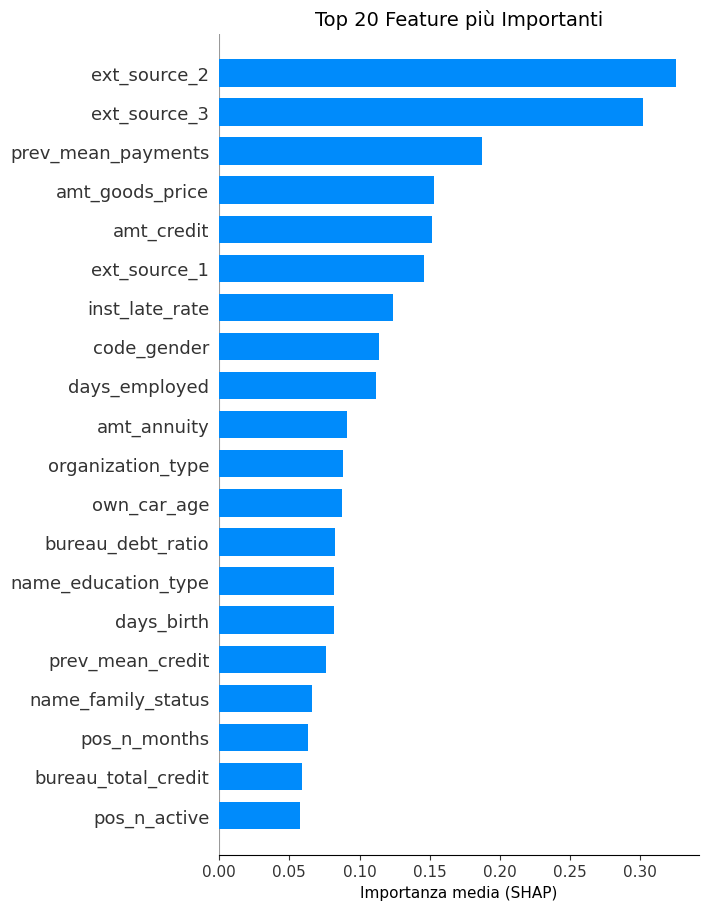

In [53]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type = 'bar',
    max_display = 20,
    show = False
)

plt.gca().set_xlabel('Importanza media (SHAP)', fontsize=11)
plt.title('Top 20 Feature più Importanti', fontsize=14)
plt.subplots_adjust(left=0.35, bottom=0.12, right=0.95)
plt.show()

### Le prime 2 feature dominano il modello
**ext_source_2** e **ext_source_3** sono i predittori più potenti, con un
distacco netto su tutte le altre. Sono punteggi di rating esterni (forniti
da agenzie di credito) che sintetizzano la storia creditizia del cliente.
Un valore basso significa alta probabilità di default.

### Il comportamento passato conta più del reddito
7 feature su 20 provengono dal feature engineering sulle sorgenti esterne
(`prev_`, `inst_`, `bureau_`, `pos_`), confermando che il comportamento
storico del cliente è più predittivo delle sue caratteristiche anagrafiche
attuali. In particolare `prev_mean_payments` entra direttamente al 3° posto.

### Le feature più significative spiegabili al business

| Feature | Significato | Direzione rischio |
|---|---|---|
| ext_source_2/3 | Rating creditizio esterno | Basso → più rischio |
| prev_mean_payments | Rate medie prestiti precedenti | Alte → più rischio |
| amt_goods_price | Prezzo del bene finanziato | Alto → più rischio |
| amt_credit | Importo del prestito richiesto | Alto → più rischio |
| days_employed | Anzianità lavorativa | Bassa → più rischio |
| inst_late_rate | Percentuale rate in ritardo | Alta → molto più rischio |
| code_gender | Genere del cliente | — vedere beeswarm |
| own_car_age | Età dell'auto posseduta | — vedere beeswarm |
| days_birth | Età del cliente | Giovane → più rischio |
| bureau_debt_ratio | Rapporto debito/credito su terzi | Alto → più rischio |

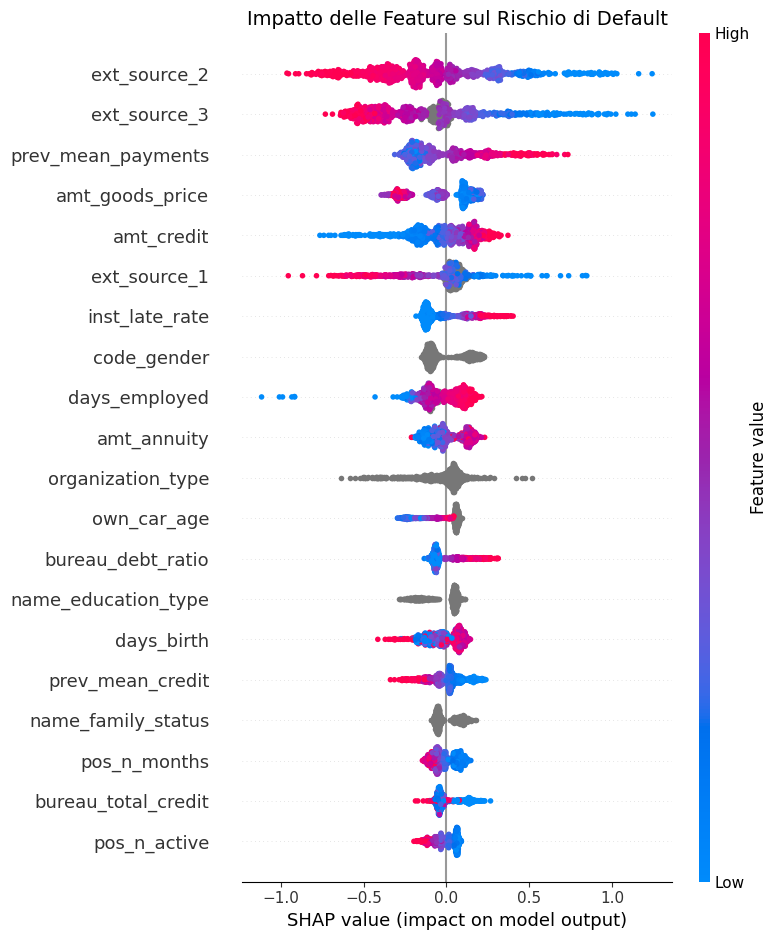

In [54]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    max_display = 20,
    show        = False
)
plt.title('Impatto delle Feature sul Rischio di Default', fontsize=14)
plt.tight_layout()
plt.show()

### Lettura del Beeswarm Plot
Ogni punto rappresenta un cliente. Il colore indica il valore della feature
(rosso = alto, blu = basso). La posizione sull'asse X indica l'impatto
sulla previsione di default (destra = più rischio, sinistra = meno rischio).

**Letture chiave:**
- **ext_source_2/3**: clienti con rating basso (blu) spostati a destra verso
  il default, rating alto (rosso) a sinistra — relazione forte e netta,
  la più netta nell'intero modello.
- **prev_mean_payments**: punti rossi a destra — valori alti di rate medie sui prestiti
  precedenti aumentano il rischio. Distribuzione più dispersa rispetto alle altre
  feature del feature engineering — il range di impatto è il più esteso tra le feature derivate.
- **days_employed**: pochi punti blu isolati a sinistra rappresentano clienti
  con alta anzianità lavorativa — fortemente protettivi. La massa è centrata
  sullo zero, con outlier rossi a destra.
- **inst_late_rate**: punti rossi a destra — percentuale alta di rate in
  ritardo spinge verso il default. Distribuzione asimmetrica: la maggioranza
  dei clienti ha un tasso di ritardo basso (blu, centrati); i pochi con tasso alto fanno la differenza.
- **code_gender** e **organization_type**: distribuzione grigia — categoriche
  con molte categorie, SHAP le gestisce ma la lettura visiva è meno immediata
  rispetto alle numeriche.
- **bureau_debt_ratio**: punti rossi a destra — rapporto debito/credito alto
  aumenta il rischio, relazione chiara e concentrata.
- **prev_refuse_rate**: distribuzione bimodale — chi ha tasso di rifiuto
  alto (rosso) ha un outlier marcato a destra oltre 1.0, segnale forte
  anche se raro.

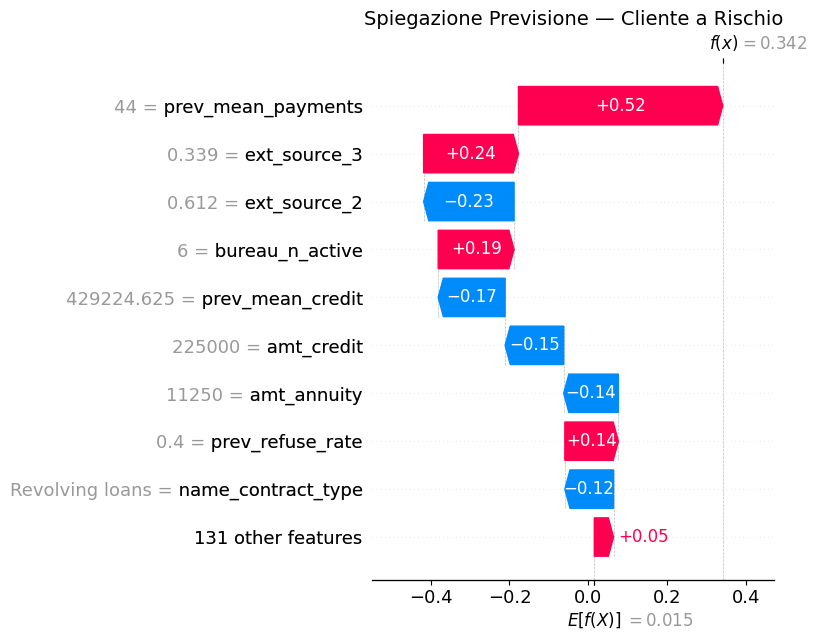

In [55]:
idx_risk = X_test[y_test == 1].index[0]
person = X_test.loc[[idx_risk]]

shap_person = explainer.shap_values(person)

shap.plots.waterfall(
    shap.Explanation(
        values        = shap_person[0],
        base_values   = explainer.expected_value,
        data          = person.values[0],
        feature_names = X_test.columns.tolist()
    ),
    show = False
)

plt.title('Spiegazione Previsione — Cliente a Rischio', fontsize=14)
plt.tight_layout()
plt.show()

### Spiegazione Previsione — Cliente a Rischio

Il waterfall mostra come il modello è arrivato alla probabilità finale
partendo da `E[f(x)]` — la probabilità media di default nella popolazione.
La distanza tra i due valori indica quanto questo cliente si discosta
dal profilo medio.

**Fattori di rischio (rosso — spingono verso il default):**
- `prev_mean_payments` — il contributo più alto in assoluto:
  un numero elevato di rate medie indica abitudine a prestiti
  molto lunghi e onerosi
- `ext_source_3` — rating esterno basso
- `bureau_n_active` — molti crediti attivi simultaneamente,
  esposizione elevata
- `prev_refuse_rate` — alta percentuale di domande precedenti rifiutate
- `ext_source_1` — ulteriore rating esterno basso

**Fattori protettivi (blu — abbassano il rischio):**
- `ext_source_2` — rating esterno nella norma, parzialmente protettivo
- `name_contract_type` — tipo contratto associato a profili meno rischiosi
- `prev_mean_credit` — credito medio alto concesso in passato,
  segnale di affidabilità riconosciuta
- `amt_credit` — importo prestito attuale relativamente contenuto
- `other features` — il resto delle feature bilancia leggermente verso il basso

**Lettura complessiva:**
Il cliente viene classificato ad alto rischio principalmente per il
comportamento sui prestiti precedenti — rate molto lunghe, tasso di
rifiuto elevato e molti crediti attivi simultaneamente — nonostante
alcuni rating esterni nella norma che parzialmente lo proteggono.

In [56]:
prob = xgb_final.predict_proba(person)[0][1]
outcome = "ALTO RISCHIO ⚠️" if prob >= threshold_optimal else "BASSO RISCHIO"

shap_series = pd.Series(shap_person[0], index=X_test.columns)

risk_factors       = shap_series[shap_series > 0].nlargest(3)
protection_factors = shap_series[shap_series < 0].nsmallest(3)

print("=" * 60)
print(f"  VALUTAZIONE RISCHIO CLIENTE — ID: {idx_risk}")
print("=" * 60)
print(f"\n  ESITO:               {outcome}")
print(f"  Probabilità default: {prob*100:.1f}%")
print(f"  Soglia di allerta:   {threshold_optimal*100:.1f}%")

print(f"\n  FATTORI DI RISCHIO (rosso nel grafico):")
for feat, val in risk_factors.items():
    real_value = person[feat].values[0]
    real_value_str = f"{real_value:.2f}" if isinstance(real_value, (int, float)) else str(real_value)
    print(f"  ▲ {feat}: {real_value_str}  (impatto: +{val:.3f})")

print(f"\n  FATTORI PROTETTIVI (blu nel grafico):")
for feat, val in protection_factors.items():
    real_value = person[feat].values[0]
    real_value_str = f"{real_value:.2f}" if isinstance(real_value, (int, float)) else str(real_value)
    print(f"  ▼ {feat}: {real_value_str}  (impatto: {val:.3f})")

print(f"\n  RACCOMANDAZIONE:")
if prob >= threshold_optimal:
    print("  Richiedere documentazione aggiuntiva e")
    print("  valutazione manuale da parte del risk manager.")
else:
    print("  Profilo compatibile con l'erogazione del credito.")
    print(f"  Monitorare: probabilità al {prob*100:.1f}% — vicino alla soglia.")
print("=" * 60)

  VALUTAZIONE RISCHIO CLIENTE — ID: 394494

  ESITO:               ALTO RISCHIO ⚠️
  Probabilità default: 58.5%
  Soglia di allerta:   53.4%

  FATTORI DI RISCHIO (rosso nel grafico):
  ▲ prev_mean_payments: 44.00  (impatto: +0.519)
  ▲ ext_source_3: 0.34  (impatto: +0.241)
  ▲ bureau_n_active: 6.00  (impatto: +0.193)

  FATTORI PROTETTIVI (blu nel grafico):
  ▼ ext_source_2: 0.61  (impatto: -0.230)
  ▼ prev_mean_credit: 429224.62  (impatto: -0.170)
  ▼ amt_credit: 225000.00  (impatto: -0.149)

  RACCOMANDAZIONE:
  Richiedere documentazione aggiuntiva e
  valutazione manuale da parte del risk manager.


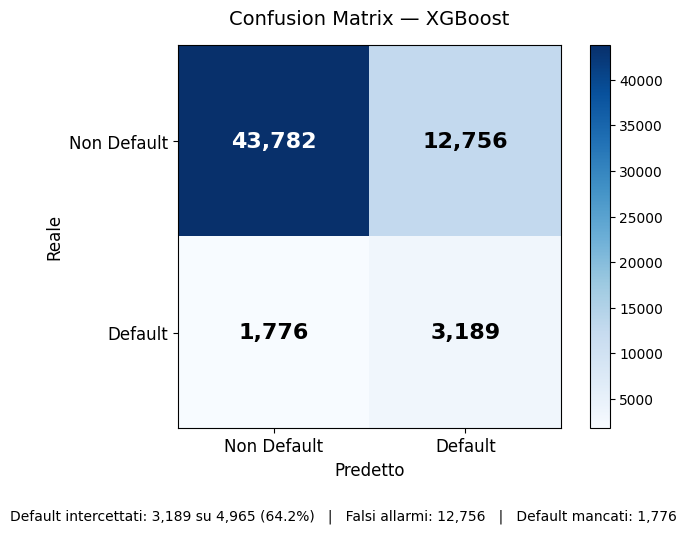

In [57]:
cm = confusion_matrix(y_test, y_pred_finale)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

classi = ['Non Default', 'Default']
ax.set_xticks([0, 1]); ax.set_xticklabels(classi, fontsize=12)
ax.set_yticks([0, 1]); ax.set_yticklabels(classi, fontsize=12)

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}',
                ha='center', va='center', fontsize=16, fontweight='bold',
                color='white' if cm[i,j] > thresh else 'black')

ax.set_xlabel('Predetto', fontsize=12)
ax.set_ylabel('Reale', fontsize=12)
ax.set_title('Confusion Matrix — XGBoost', fontsize=14, pad=15)

plt.figtext(0.5, -0.05,
    f'Default intercettati: {tp:,} su {tp+fn:,} ({tp/(tp+fn)*100:.1f}%)   |   '
    f'Falsi allarmi: {fp:,}   |   Default mancati: {fn:,}',
    ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Interpretazione della Confusion Matrix

Il modello produce quattro tipologie di esito sul test set:

| Risultato | Significato aziendale |
|---|---|
| Veri Positivi (TP) | Default reali correttamente bloccati |
| Falsi Negativi (FN) | Default non rilevati — perdita economica |
| Falsi Positivi (FP) | Clienti buoni rifiutati — mancato guadagno |
| Veri Negativi (TN) | Clienti buoni correttamente approvati |

**La scelta della soglia è una decisione di business, non tecnica.**
Abbassando la soglia si intercettano più default (Recall sale)
ma si rifiutano più clienti buoni (Precision scende).
La soglia ottimale è stata cercata sul validation set per massimizzare
il Recall mantenendo una Precision minima del 20% — ovvero per ogni
5 clienti bloccati, almeno 1 è un default reale. Sul test set la
Precision risultante può discostarsi leggermente dal vincolo:
differenza fisiologica tra validation e test set, non un errore
del modello.

**In termini economici:**
Il modello intercetta la maggioranza dei default reali a fronte di
un numero di falsi allarmi. Genera valore economico netto positivo
se il costo medio di un default non rilevato supera il margine perso
sui clienti buoni erroneamente rifiutati — condizione tipicamente
verificata nel credito al consumo, dove le perdite su un default
superano di gran lunga il margine su un singolo prestito.

In [58]:
df_test = pd.read_csv(dirname + '/application_test.csv', index_col='SK_ID_CURR')

df_test = df_test.drop(columns=cols_to_drop)
df_test['DAYS_EMPLOYED'] = df_test['DAYS_EMPLOYED'].replace(365243, np.nan)

df_test = df_test.join(bureau_agg,    how='left'); df_test[bureau_col] = df_test[bureau_col].fillna(0)
df_test = df_test.join(prev_agg,      how='left'); df_test[prev_col]   = df_test[prev_col].fillna(0)
df_test = df_test.join(inst_agg,      how='left'); df_test[inst_col]   = df_test[inst_col].fillna(0)
df_test = df_test.join(pos_agg,       how='left'); df_test[pos_col]    = df_test[pos_col].fillna(0)
df_test = df_test.join(cc_agg,        how='left'); df_test[cc_col]     = df_test[cc_col].fillna(0)
df_test = df_test.join(bureau_bb_agg, how='left'); df_test[bb_col]     = df_test[bb_col].fillna(0)

df_test.columns = df_test.columns.str.lower()
cat_cols = df_test.select_dtypes(include='object').columns
df_test[cat_cols] = df_test[cat_cols].astype('category')

X_submission = df_test.reindex(columns=X_train.columns)

y_sub_prob = xgb_final.predict_proba(X_submission)[:, 1]
submission = pd.DataFrame({'SK_ID_CURR': df_test.index, 'TARGET': y_sub_prob})
submission.to_csv('submission.csv', index=False)